# Fooling LIME, SHAP y Anchors — Readmisión Hospitalaria

Reproducción y extensión del framework adversarial de Slack et al. (2020)
sobre el dataset de readmisión hospitalaria de diabéticos (UCI, ~100k instancias).

**Atributo sensible:** raza (`race`) — igual que COMPAS en el paper original.

**Optimizaciones para 5-10 min en CPU:**
- SHAP: KernelExplainer sobre submuestra de 50 instancias, nsamples=100
- Anchors: 30 instancias, beam_size=2
- OOD classifier: RandomForest con n_jobs=-1 (todos los cores)
- LIME: 50 instancias, num_samples=2000

**Estructura:**
1. Instalación y carga
2. Preprocesamiento
3. Análisis del atributo sensible
4. Clasificador sesgado f y clasificador inocuo ψ
5. OOD Classifiers (LIME, SHAP, Anchors)
6. Scaffolded classifier e
7. Evaluación LIME
8. Evaluación SHAP
9. Evaluación Anchors
10. Comparativa final LIME vs SHAP vs Anchors

## 1. Instalación y carga

In [ ]:
#!pip install lime shap alibi scikit-learn pandas numpy matplotlib seaborn -q

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report
from sklearn.decomposition import PCA

print("Librerías cargadas")

Librerías cargadas


In [2]:
# Descarga directa desde UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00296/dataset_diabetes.zip"
!wget -q {url} -O dataset_diabetes.zip && unzip -q -o dataset_diabetes.zip

df_raw = pd.read_csv('dataset_diabetes/diabetic_data.csv', na_values='?')
print(f"Dataset cargado: {df_raw.shape}")
df_raw.head(3)

Dataset cargado: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


## 2. Preprocesamiento

Seleccionamos features relevantes, binarizamos el target y codificamos categóricas.
El atributo sensible es `race` — igual que en los experimentos COMPAS del paper.

In [3]:
# --- Selección de features ---
# Eliminamos identificadores, columnas con >40% nulos, y leakage directo
DROP_COLS = [
    'encounter_id', 'patient_nbr',           # identificadores
    'examide', 'citoglipton',                 # constantes
    'weight', 'payer_code', 'medical_specialty',  # >40% nulos
]
df = df_raw.drop(columns=DROP_COLS, errors='ignore').copy()

# --- Target: readmisión en <30 días ---
df['target'] = (df['readmitted'] == '<30').astype(int)
df = df.drop(columns=['readmitted'])

# --- Atributo sensible: raza ---
# Binarizamos: Caucasian=0, otros=1 (para que f sea perfectamente discriminatorio)
df = df.dropna(subset=['race'])
df['race_binary'] = (df['race'] != 'Caucasian').astype(int)

# --- Eliminar race original para que no entre como feature directa ---
df = df.drop(columns=['race'])

# --- Codificar categóricas restantes ---
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')
    df[col] = le.fit_transform(df[col].astype(str))

# Rellenar numéricos
df = df.fillna(df.median(numeric_only=True))

# --- Separar X e y ---
sensitive_feature = 'race_binary'
feature_cols = [c for c in df.columns if c not in ['target']]
X_df = df[feature_cols]
y = df['target'].values

feature_names = feature_cols
sensitive_idx = feature_names.index(sensitive_feature)

print(f"Shape final: {X_df.shape}")
print(f"Distribución target: {pd.Series(y).value_counts().to_dict()}")
print(f"Tasa de readmisión <30d: {y.mean()*100:.1f}%")
print(f"Índice atributo sensible (race_binary): {sensitive_idx}")

Shape final: (99493, 42)
Distribución target: {0: 88324, 1: 11169}
Tasa de readmisión <30d: 11.2%
Índice atributo sensible (race_binary): 41


In [4]:
# Split 90/10 como en el paper
X_train, X_test, y_train, y_test = train_test_split(
    X_df.values, y, test_size=0.1, random_state=42, stratify=y
)

# Feature sintética no correlacionada con race_binary
np.random.seed(42)
uncorrelated_train = np.random.randint(0, 2, size=len(X_train))
uncorrelated_test  = np.random.randint(0, 2, size=len(X_test))

corr = np.corrcoef(X_train[:, sensitive_idx], uncorrelated_train)[0, 1]
print(f"Correlación race_binary ↔ uncorrelated_feature_1: {corr:.4f} (debe ser ~0)")

feature_names_ext = feature_names + ['uncorrelated_feature_1']
X_train_ext = np.column_stack([X_train, uncorrelated_train])
X_test_ext  = np.column_stack([X_test,  uncorrelated_test])

print(f"Train: {X_train_ext.shape} | Test: {X_test_ext.shape}")

Correlación race_binary ↔ uncorrelated_feature_1: -0.0027 (debe ser ~0)
Train: (89543, 43) | Test: (9950, 43)


## 3. Análisis del atributo sensible

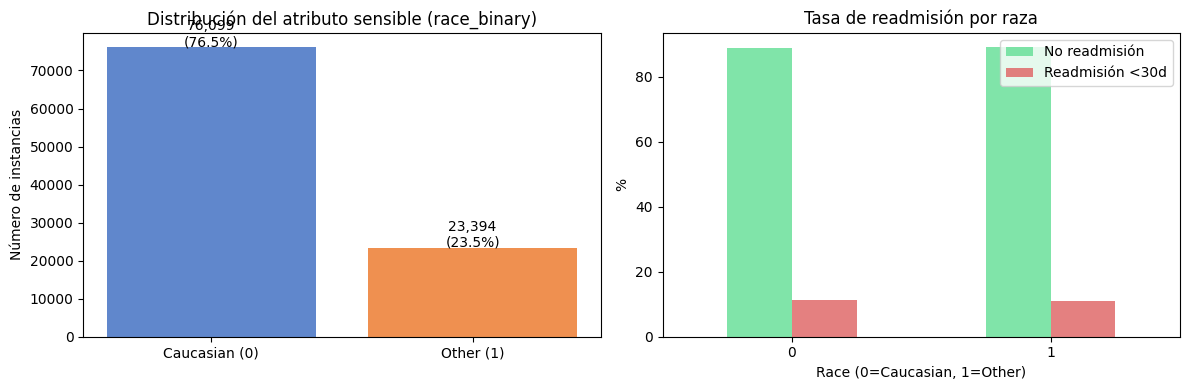

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

race_counts = pd.Series(X_df['race_binary']).value_counts().sort_index()
axes[0].bar(['Caucasian (0)', 'Other (1)'], race_counts.values,
            color=['#4472C4', '#ED7D31'], alpha=0.85)
axes[0].set_title('Distribución del atributo sensible (race_binary)')
axes[0].set_ylabel('Número de instancias')
for i, v in enumerate(race_counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(X_df)*100:.1f}%)',
                ha='center', fontsize=10)

ct = pd.crosstab(X_df['race_binary'], y, normalize='index') * 100
ct.plot(kind='bar', ax=axes[1], color=['#6AE09A', '#E06A6A'], alpha=0.85)
axes[1].set_title('Tasa de readmisión por raza')
axes[1].set_xlabel('Race (0=Caucasian, 1=Other)')
axes[1].set_ylabel('%')
axes[1].legend(['No readmisión', 'Readmisión <30d'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 4. Clasificadores f y ψ

In [6]:
def f_biased(X_input):
    """Discrimina únicamente por raza: Other (1) → readmisión, Caucasian (0) → no."""
    if isinstance(X_input, pd.DataFrame):
        return X_input['race_binary'].values.astype(int)
    return X_input[:, sensitive_idx].astype(int)

# Verificar en test
preds_f = f_biased(X_test)
print(f"Distribución predicciones f: {np.unique(preds_f, return_counts=True)}")
print(f"Demographic parity ratio: {preds_f.mean():.3f}")
print("(ratio=0 significaría discriminación perfecta; aquí race_binary ya es 0/1)")

def psi_unbiased(X_input):
    """Clasificador inocuo: usa uncorrelated_feature_1 (última columna)."""
    return X_input[:, -1].astype(int)

Distribución predicciones f: (array([0, 1]), array([7630, 2320]))
Demographic parity ratio: 0.233
(ratio=0 significaría discriminación perfecta; aquí race_binary ya es 0/1)


## 5. OOD Classifiers

Entrenamos tres OOD classifiers separados, uno por método de explicación,
cada uno con el tipo de perturbación que ese método genera internamente.

In [7]:
def build_ood_classifier(X_real, X_perturbed, label=''):
    """Entrena y evalúa un OOD classifier."""
    # Filtrar perturbaciones que coincidan exactamente con datos reales
    real_set = set(map(tuple, X_real))
    X_pert_filtered = np.array([x for x in X_perturbed if tuple(x) not in real_set])
    if len(X_pert_filtered) == 0:
        X_pert_filtered = X_perturbed

    X_ood = np.vstack([X_real, X_pert_filtered])
    y_ood = np.array([0]*len(X_real) + [1]*len(X_pert_filtered))

    clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
    clf.fit(X_ood, y_ood)

    f1 = f1_score(y_ood, clf.predict(X_ood))
    print(f"OOD Classifier [{label}] F1: {f1:.4f} | "
          f"train size: {len(X_ood):,} ({len(X_real):,} real + {len(X_pert_filtered):,} pert.)")
    return clf, f1


# Usamos una submuestra para el OOD (suficiente con 20k de cada clase)
N_OOD = 20_000
idx = np.random.choice(len(X_train_ext), N_OOD, replace=False)
X_train_ood = X_train_ext[idx]

# --- OOD para LIME: ruido gaussiano N(0,1) ---
t0 = time.time()
X_pert_lime = X_train_ood + np.random.normal(0, 1, X_train_ood.shape)
ood_clf_lime, f1_lime = build_ood_classifier(X_train_ood, X_pert_lime, 'LIME')
print(f"  Tiempo: {time.time()-t0:.1f}s")

# --- OOD para SHAP: reemplazo con background (kmeans aproximado con muestra aleatoria) ---
t0 = time.time()
from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(n_clusters=10, random_state=42, n_init=3)
kmeans.fit(X_train_ood)
background_centers = kmeans.cluster_centers_

def generate_shap_perturbations(X_real, bg_centers, n=None):
    if n is None: n = len(X_real)
    perturbed = []
    for _ in range(n):
        base = X_real[np.random.randint(len(X_real))].copy()
        bg = bg_centers[np.random.randint(len(bg_centers))]
        mask = np.random.randint(0, 2, size=base.shape[0]).astype(bool)
        base[mask] = bg[mask]
        perturbed.append(base)
    return np.array(perturbed)

X_pert_shap = generate_shap_perturbations(X_train_ood, background_centers)
ood_clf_shap, f1_shap = build_ood_classifier(X_train_ood, X_pert_shap, 'SHAP')
print(f"  Tiempo: {time.time()-t0:.1f}s")

# --- OOD para Anchors: muestreo marginal ---
t0 = time.time()
def generate_anchor_perturbations(X_real, n=None, ratio=0.5):
    if n is None: n = len(X_real)
    n_feat = X_real.shape[1]
    perturbed = []
    for _ in range(n):
        base = X_real[np.random.randint(len(X_real))].copy()
        n_pert = max(1, int(n_feat * ratio))
        for fi in np.random.choice(n_feat, n_pert, replace=False):
            base[fi] = X_real[np.random.randint(len(X_real)), fi]
        perturbed.append(base)
    return np.array(perturbed)

X_pert_anchors = generate_anchor_perturbations(X_train_ood)
ood_clf_anchors, f1_anchors = build_ood_classifier(X_train_ood, X_pert_anchors, 'Anchors')
print(f"  Tiempo: {time.time()-t0:.1f}s")

OOD Classifier [LIME] F1: 1.0000 | train size: 40,000 (20,000 real + 20,000 pert.)
  Tiempo: 0.5s
OOD Classifier [SHAP] F1: 1.0000 | train size: 40,000 (20,000 real + 20,000 pert.)
  Tiempo: 0.7s
OOD Classifier [Anchors] F1: 1.0000 | train size: 40,000 (20,000 real + 20,000 pert.)
  Tiempo: 1.3s


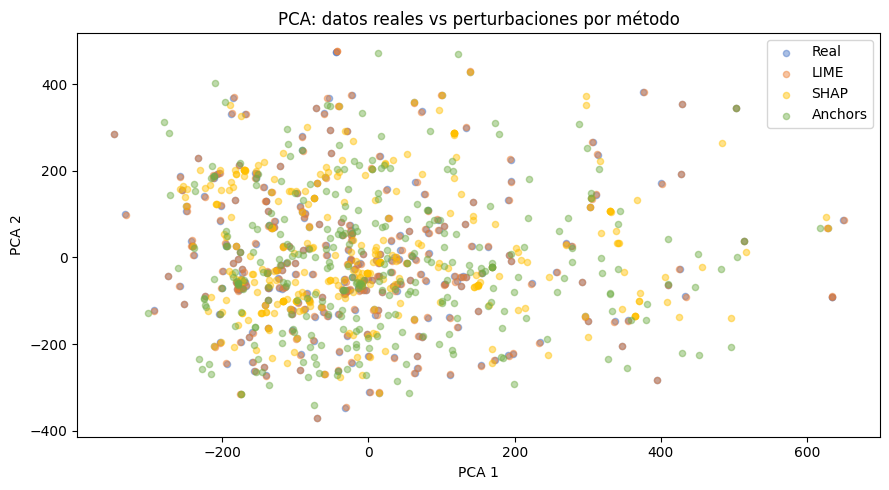

→ Anchors debería solaparse más con los datos reales que LIME


In [8]:
# Visualización PCA: comparar las tres estrategias de perturbación
pca = PCA(n_components=2)
idx_vis = np.random.choice(len(X_train_ood), 300, replace=False)
X_vis = X_train_ood[idx_vis]

combined = np.vstack([
    X_vis,
    X_vis + np.random.normal(0, 1, X_vis.shape),  # LIME
    generate_shap_perturbations(X_vis, background_centers, n=300),
    generate_anchor_perturbations(X_vis, n=300)
])
labels_pca = ['Real']*300 + ['LIME']*300 + ['SHAP']*300 + ['Anchors']*300
reduced = pca.fit_transform(combined)

colors_pca = {'Real':'#4472C4','LIME':'#ED7D31','SHAP':'#FFC000','Anchors':'#70AD47'}
plt.figure(figsize=(9, 5))
for label, color in colors_pca.items():
    mask = np.array(labels_pca) == label
    plt.scatter(reduced[mask,0], reduced[mask,1],
                c=color, label=label, alpha=0.45, s=20)
plt.title('PCA: datos reales vs perturbaciones por método')
plt.xlabel('PCA 1'); plt.ylabel('PCA 2')
plt.legend(); plt.tight_layout(); plt.show()
print("→ Anchors debería solaparse más con los datos reales que LIME")

## 6. Scaffolded Classifier `e`

In [9]:
class AdversarialClassifier:
    def __init__(self, ood_clf, f_fn, threshold=0.5):
        self.ood_clf = ood_clf
        self.f_fn = f_fn
        self.threshold = threshold

    def predict(self, X):
        if X.ndim == 1: X = X.reshape(1, -1)
        preds = np.zeros(len(X), dtype=int)
        is_ood = self.ood_clf.predict_proba(X)[:, 1] > self.threshold
        if np.any(~is_ood): preds[~is_ood] = self.f_fn(X[~is_ood])
        if np.any(is_ood):  preds[is_ood]  = (X[is_ood, -1] > 0).astype(int)
        return preds

    def predict_proba(self, X):
        if X.ndim == 1: X = X.reshape(1, -1)
        p = self.predict(X).astype(float)
        return np.column_stack([1-p, p])


e_lime    = AdversarialClassifier(ood_clf_lime,    f_biased)
e_shap    = AdversarialClassifier(ood_clf_shap,    f_biased)
e_anchors = AdversarialClassifier(ood_clf_anchors, f_biased)

preds_f_test = f_biased(X_test_ext)
for name, clf in [('LIME', e_lime), ('SHAP', e_shap), ('Anchors', e_anchors)]:
    fid = np.mean(clf.predict(X_test_ext) == preds_f_test)
    print(f"Fidelidad e_{name} → f: {fid:.4f}")

Fidelidad e_LIME → f: 1.0000
Fidelidad e_SHAP → f: 0.9956
Fidelidad e_Anchors → f: 0.9320


## 7. Evaluación LIME

In [10]:
import lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_ext[:5000],   # submuestra para velocidad
    feature_names=feature_names_ext,
    class_names=['No readmisión', 'Readmisión'],
    discretize_continuous=False,
    random_state=42
)

def get_lime_top3(explainer, predict_fn, X_instances, num_samples=2000):
    top3_list = []
    for i, inst in enumerate(X_instances):
        exp = explainer.explain_instance(
            inst, predict_fn,
            num_features=len(feature_names_ext),
            num_samples=num_samples
        )
        sorted_feats = sorted(exp.as_list(), key=lambda x: abs(x[1]), reverse=True)
        top3_list.append([f[0] for f in sorted_feats[:3]])
        if (i+1) % 10 == 0: print(f"  {i+1}/{len(X_instances)}", end='\r')
    return top3_list

N_LIME = 50
idx_eval = np.random.choice(len(X_test_ext), N_LIME, replace=False)
X_eval = X_test_ext[idx_eval]

print(f"Generando LIME para f ({N_LIME} instancias)...")
t0 = time.time()
top3_f_lime = get_lime_top3(
    lime_explainer,
    lambda x: np.column_stack([1-f_biased(x), f_biased(x)]),
    X_eval
)
print(f"\n✓ {time.time()-t0:.1f}s")

print(f"Generando LIME para e ({N_LIME} instancias)...")
t0 = time.time()
top3_e_lime = get_lime_top3(lime_explainer, e_lime.predict_proba, X_eval)
print(f"\n✓ {time.time()-t0:.1f}s")

Generando LIME para f (50 instancias)...
  50/50
✓ 0.3s
Generando LIME para e (50 instancias)...
  50/50
✓ 1.4s


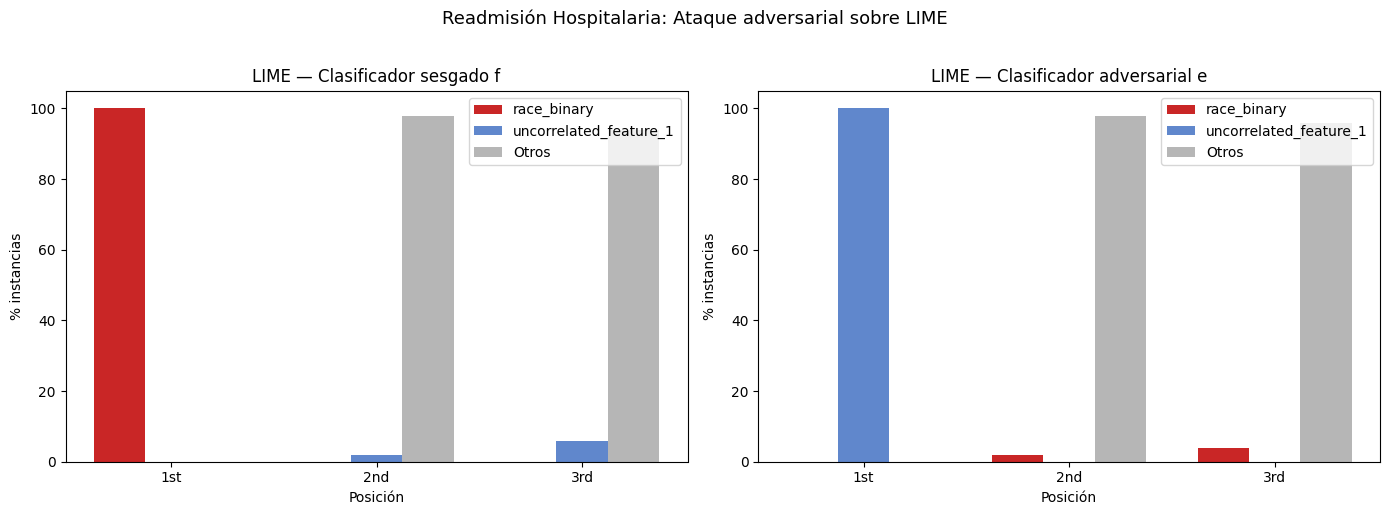


resumen LIME:
  race_binary rank1 en f: 100.0%
  race_binary rank1 en e: 0.0%
  Efectividad del ataque: 100.0pp


In [11]:
def compute_rank_stats_lime(top3_list, sensitive_feat, uncorrelated_feat):
    n = len(top3_list)
    stats = {sensitive_feat: [0,0,0], uncorrelated_feat: [0,0,0], 'others': [0,0,0]}
    for top3 in top3_list:
        for rank, feat_str in enumerate(top3):
            if sensitive_feat in feat_str:      stats[sensitive_feat][rank] += 1
            elif uncorrelated_feat in feat_str: stats[uncorrelated_feat][rank] += 1
            else:                               stats['others'][rank] += 1
    for k in stats: stats[k] = [v/n*100 for v in stats[k]]
    return stats

stats_f_lime = compute_rank_stats_lime(top3_f_lime, 'race_binary', 'uncorrelated_feature_1')
stats_e_lime = compute_rank_stats_lime(top3_e_lime, 'race_binary', 'uncorrelated_feature_1')

colors_bar = {'race_binary': '#C00000', 'uncorrelated_feature_1': '#4472C4', 'others': '#A9A9A9'}
ranks = ['1st', '2nd', '3rd']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (stats, title) in zip(axes, [
    (stats_f_lime, 'Clasificador sesgado f'),
    (stats_e_lime, 'Clasificador adversarial e')
]):
    x = np.arange(3)
    for i, (feat, color) in enumerate(colors_bar.items()):
        ax.bar(x + i*0.25, stats[feat], 0.25,
               label=feat if feat != 'others' else 'Otros', color=color, alpha=0.85)
    ax.set_xticks(x + 0.25); ax.set_xticklabels(ranks)
    ax.set_xlabel('Posición'); ax.set_ylabel('% instancias')
    ax.set_title(f'LIME — {title}'); ax.legend(); ax.set_ylim(0, 105)

plt.suptitle('Readmisión Hospitalaria: Ataque adversarial sobre LIME', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print(f"\nresumen LIME:")
print(f"  race_binary rank1 en f: {stats_f_lime['race_binary'][0]:.1f}%")
print(f"  race_binary rank1 en e: {stats_e_lime['race_binary'][0]:.1f}%")
print(f"  Efectividad del ataque: {stats_f_lime['race_binary'][0] - stats_e_lime['race_binary'][0]:.1f}pp")

## 8. Evaluación SHAP

In [12]:
import shap

# Background: los centros kmeans ya calculados
background_shap = shap.kmeans(X_train_ext[:5000], 10)

N_SHAP = 50
X_shap_eval = X_test_ext[:N_SHAP]

print(f"Calculando SHAP values para f ({N_SHAP} instancias, nsamples=100)...")
t0 = time.time()
shap_exp_f = shap.KernelExplainer(
    lambda x: np.column_stack([1-f_biased(x), f_biased(x)]),
    background_shap
)
shap_vals_f = shap_exp_f.shap_values(X_shap_eval, nsamples=100)
print(f"✓ {time.time()-t0:.1f}s")

print(f"Calculando SHAP values para e ({N_SHAP} instancias, nsamples=100)...")
t0 = time.time()
shap_exp_e = shap.KernelExplainer(e_shap.predict_proba, background_shap)
shap_vals_e = shap_exp_e.shap_values(X_shap_eval, nsamples=100)
print(f"✓ {time.time()-t0:.1f}s")

Calculando SHAP values para f (50 instancias, nsamples=100)...


100%|██████████| 50/50 [00:00<00:00, 307.44it/s]


✓ 0.2s
Calculando SHAP values para e (50 instancias, nsamples=100)...


100%|██████████| 50/50 [00:01<00:00, 31.49it/s]

✓ 1.6s


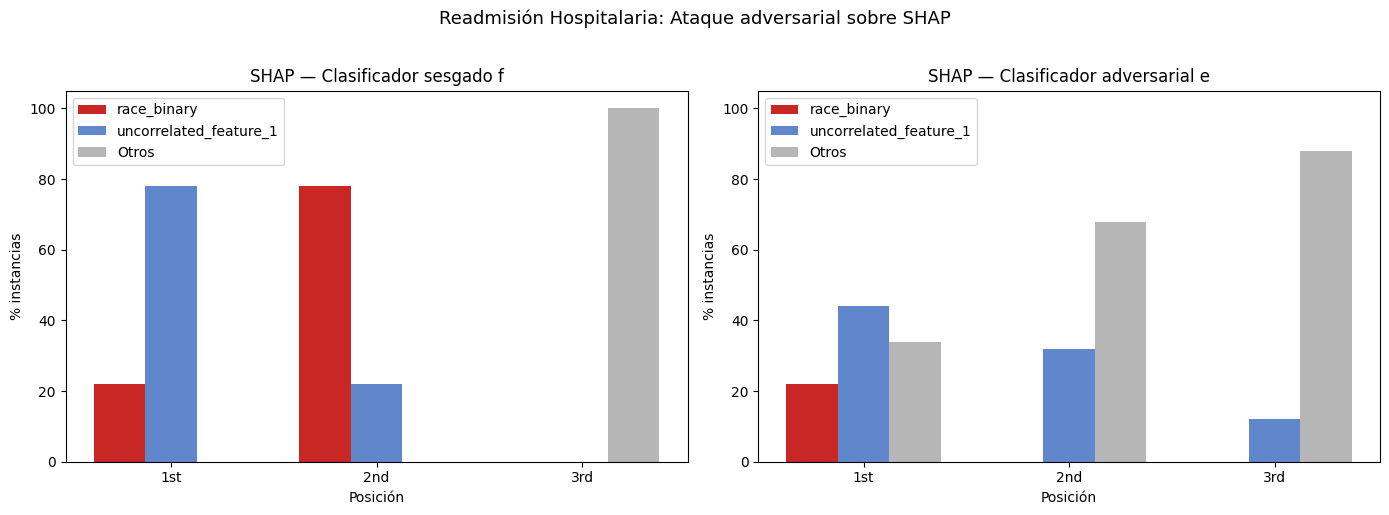


resumen SHAP:
  race_binary rank1 en f: 22.0%
  race_binary rank1 en e: 22.0%
  Efectividad del ataque: 0.0pp


In [13]:
def get_shap_top3(shap_vals, class_idx=1):
    if isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
        vals = shap_vals[:, :, class_idx]
    elif isinstance(shap_vals, list):
        vals = shap_vals[class_idx]
    else:
        vals = shap_vals
    if vals.ndim == 1: vals = vals.reshape(1, -1)
    return [[feature_names_ext[int(i)] for i in np.argsort(np.abs(row))[::-1][:3]]
            for row in vals]

def compute_rank_stats_shap(top3_list, sensitive_feat, uncorrelated_feat):
    n = len(top3_list)
    stats = {sensitive_feat: [0,0,0], uncorrelated_feat: [0,0,0], 'others': [0,0,0]}
    for top3 in top3_list:
        for rank, feat in enumerate(top3):
            if feat == sensitive_feat:      stats[sensitive_feat][rank] += 1
            elif feat == uncorrelated_feat: stats[uncorrelated_feat][rank] += 1
            else:                           stats['others'][rank] += 1
    for k in stats: stats[k] = [v/n*100 for v in stats[k]]
    return stats

top3_f_shap = get_shap_top3(shap_vals_f)
top3_e_shap = get_shap_top3(shap_vals_e)
stats_f_shap = compute_rank_stats_shap(top3_f_shap, 'race_binary', 'uncorrelated_feature_1')
stats_e_shap = compute_rank_stats_shap(top3_e_shap, 'race_binary', 'uncorrelated_feature_1')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (stats, title) in zip(axes, [
    (stats_f_shap, 'Clasificador sesgado f'),
    (stats_e_shap, 'Clasificador adversarial e')
]):
    x = np.arange(3)
    for i, (feat, color) in enumerate(colors_bar.items()):
        ax.bar(x + i*0.25, stats[feat], 0.25,
               label=feat if feat != 'others' else 'Otros', color=color, alpha=0.85)
    ax.set_xticks(x + 0.25); ax.set_xticklabels(ranks)
    ax.set_xlabel('Posición'); ax.set_ylabel('% instancias')
    ax.set_title(f'SHAP — {title}'); ax.legend(); ax.set_ylim(0, 105)

plt.suptitle('Readmisión Hospitalaria: Ataque adversarial sobre SHAP', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print(f"\nresumen SHAP:")
print(f"  race_binary rank1 en f: {stats_f_shap['race_binary'][0]:.1f}%")
print(f"  race_binary rank1 en e: {stats_e_shap['race_binary'][0]:.1f}%")
print(f"  Efectividad del ataque: {stats_f_shap['race_binary'][0] - stats_e_shap['race_binary'][0]:.1f}pp")

## 9. Evaluación Anchors

In [14]:
from alibi.explainers import AnchorTabular

# Features categóricas binarias
cat_names = {}
for feat in ['race_binary', 'gender', 'change', 'diabetesMed']:
    if feat in feature_names_ext:
        cat_names[feature_names_ext.index(feat)] = ['0', '1']
# uncorrelated_feature_1
cat_names[len(feature_names_ext)-1] = ['0', '1']

anchor_exp_f = AnchorTabular(
    predictor=lambda x: np.column_stack([1-f_biased(x), f_biased(x)]),
    feature_names=feature_names_ext,
    categorical_names=cat_names
)
anchor_exp_f.fit(X_train_ext[:5000], disc_perc=(25, 50, 75))

anchor_exp_e = AnchorTabular(
    predictor=e_anchors.predict_proba,
    feature_names=feature_names_ext,
    categorical_names=cat_names
)
anchor_exp_e.fit(X_train_ext[:5000], disc_perc=(25, 50, 75))

print("Explainers Anchors listos")

I0000 00:00:1779436903.988580    5979 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779436903.992663    5979 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779436904.338490    5979 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779436905.406321    5979 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

Explainers Anchors listos


In [15]:
def analyze_anchors(explainer, X_instances, sensitive_feat, uncorrelated_feat,
                    threshold=0.90, n_instances=30):
    results = []
    for i, inst in enumerate(X_instances[:n_instances]):
        try:
            exp = explainer.explain(inst, threshold=threshold, tau=0.15, beam_size=2)
            conds = exp.anchor
            results.append({
                'anchor': ' AND '.join(conds) if conds else '(vacío)',
                'n_conditions': len(conds),
                'has_sensitive': any(sensitive_feat in c for c in conds),
                'has_uncorrelated': any(uncorrelated_feat in c for c in conds),
                'precision': exp.precision,
                'coverage': exp.coverage
            })
        except Exception as ex:
            results.append({
                'anchor': f'ERROR', 'n_conditions': 0,
                'has_sensitive': False, 'has_uncorrelated': False,
                'precision': 0.0, 'coverage': 0.0
            })
        if (i+1) % 5 == 0: print(f"  {i+1}/{n_instances}", end='\r')
    return pd.DataFrame(results)

N_ANCHORS = 30
X_anchor_eval = X_test_ext[:N_ANCHORS]

print(f"Generando Anchors para f ({N_ANCHORS} instancias)...")
t0 = time.time()
results_f_anchors = analyze_anchors(
    anchor_exp_f, X_anchor_eval, 'race_binary', 'uncorrelated_feature_1'
)
print(f"\n✓ {time.time()-t0:.1f}s")

print(f"Generando Anchors para e ({N_ANCHORS} instancias)...")
t0 = time.time()
results_e_anchors = analyze_anchors(
    anchor_exp_e, X_anchor_eval, 'race_binary', 'uncorrelated_feature_1'
)
print(f"\n✓ {time.time()-t0:.1f}s")

Generando Anchors para f (30 instancias)...
  30/30
✓ 24.8s
Generando Anchors para e (30 instancias)...
  30/30
✓ 137.8s


In [16]:
valid_f_a = results_f_anchors[results_f_anchors['precision'] > 0]
valid_e_a = results_e_anchors[results_e_anchors['precision'] > 0]

print("=== Anchors — Clasificador sesgado f ===")
print(f"  race_binary en anchor: {valid_f_a['has_sensitive'].mean()*100:.1f}%")
print(f"  Precisión media: {valid_f_a['precision'].mean():.3f}")
print(f"  Cobertura media: {valid_f_a['coverage'].mean():.3f}")

print("\n=== Anchors — Clasificador adversarial e ===")
print(f"  race_binary en anchor: {valid_e_a['has_sensitive'].mean()*100:.1f}%")
print(f"  uncorrelated_feature en anchor: {valid_e_a['has_uncorrelated'].mean()*100:.1f}%")
print(f"  Precisión media: {valid_e_a['precision'].mean():.3f}")
print(f"  Cobertura media: {valid_e_a['coverage'].mean():.3f}")

# Ejemplos de reglas
print("\n--- Ejemplos de anchors tras el ataque ---")
for _, row in valid_e_a.head(6).iterrows():
    flag = '⚠️ SEX' if row['has_sensitive'] else '✓'
    print(f"  [{flag}] {row['anchor'][:80]}")
    print(f"        prec={row['precision']:.2f}, cov={row['coverage']:.3f}")

=== Anchors — Clasificador sesgado f ===
  race_binary en anchor: 100.0%
  Precisión media: 1.000
  Cobertura media: 0.656

=== Anchors — Clasificador adversarial e ===
  race_binary en anchor: 90.0%
  uncorrelated_feature en anchor: 10.0%
  Precisión media: 0.946
  Cobertura media: 0.707

--- Ejemplos de anchors tras el ataque ---
  [⚠️ SEX] race_binary = 0 AND glipizide-metformin <= 0.00
        prec=0.97, cov=1.000
  [⚠️ SEX] race_binary = 0
        prec=0.93, cov=0.760
  [⚠️ SEX] race_binary = 0
        prec=0.94, cov=0.760
  [⚠️ SEX] race_binary = 0
        prec=0.93, cov=0.760
  [⚠️ SEX] race_binary = 1
        prec=0.95, cov=0.240
  [✓] time_in_hospital <= 2.00 AND uncorrelated_feature_1 = 1 AND discharge_dispositio
        prec=0.91, cov=0.299


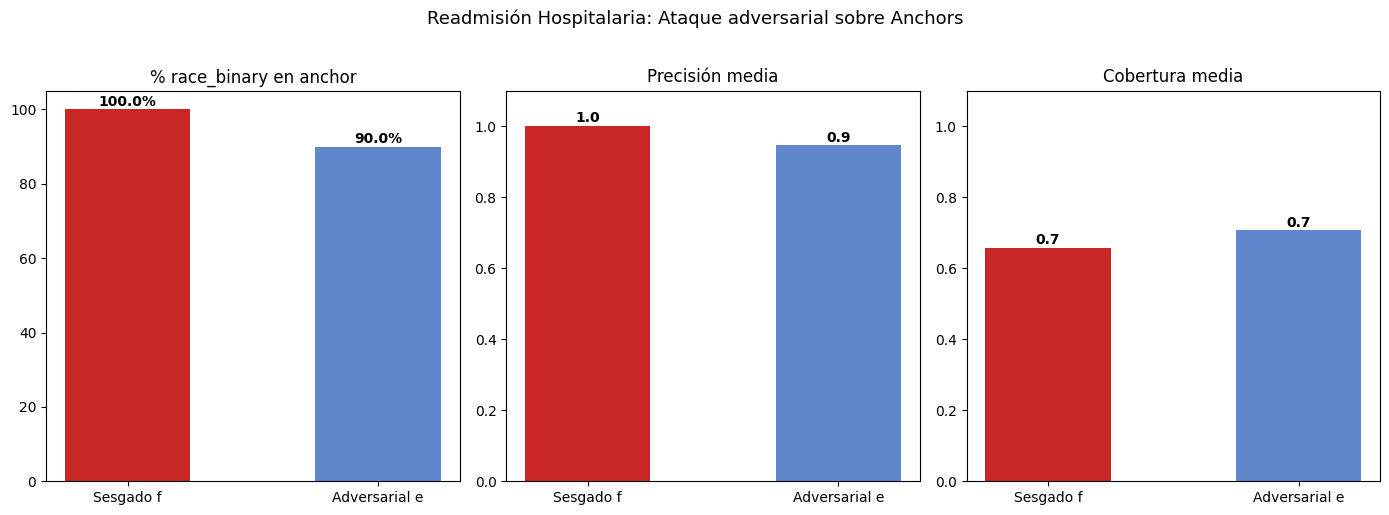

In [17]:
# Visualización Anchors
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = [
    ('% race_binary en anchor',
     [valid_f_a['has_sensitive'].mean()*100, valid_e_a['has_sensitive'].mean()*100], (0,105)),
    ('Precisión media',
     [valid_f_a['precision'].mean(), valid_e_a['precision'].mean()], (0, 1.1)),
    ('Cobertura media',
     [valid_f_a['coverage'].mean(), valid_e_a['coverage'].mean()], (0, 1.1)),
]

for ax, (title, values, ylim) in zip(axes, metrics):
    bars = ax.bar(['Sesgado f', 'Adversarial e'], values,
                  color=['#C00000', '#4472C4'], alpha=0.85, width=0.5)
    ax.set_title(title); ax.set_ylim(*ylim)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+ylim[1]*0.01,
                f'{val:.1f}' + ('%' if 'race' in title else ''),
                ha='center', fontweight='bold')

plt.suptitle('Readmisión Hospitalaria: Ataque adversarial sobre Anchors', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 10. Comparativa final: LIME vs SHAP vs Anchors

COMPARATIVA FINAL — Readmisión Hospitalaria
Atributo sensible: race_binary
Método        Antes   Después   Reducción Efectividad
-----------------------------------------------------------------
LIME         100.0%      0.0%      100.0pp      100.0%
SHAP          22.0%     22.0%        0.0pp        0.0%
Anchors      100.0%     90.0%       10.0pp       10.0%


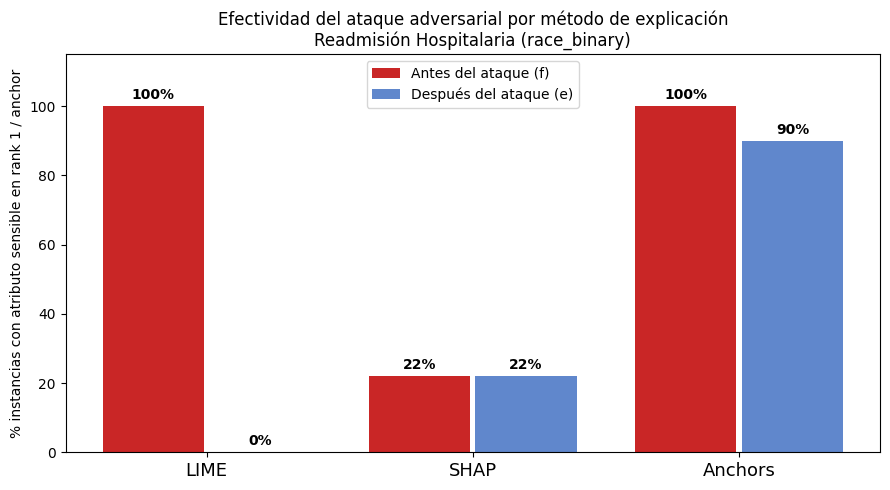

In [18]:
# Recopilar métricas
lime_f   = stats_f_lime['race_binary'][0]
lime_e   = stats_e_lime['race_binary'][0]
shap_f   = stats_f_shap['race_binary'][0]
shap_e   = stats_e_shap['race_binary'][0]
anch_f   = valid_f_a['has_sensitive'].mean()*100
anch_e   = valid_e_a['has_sensitive'].mean()*100

print("="*65)
print("COMPARATIVA FINAL — Readmisión Hospitalaria")
print("Atributo sensible: race_binary")
print("="*65)
print(f"{'Método':<10} {'Antes':>8} {'Después':>9} {'Reducción':>11} {'Efectividad'}")
print("-"*65)
for name, before, after in [
    ('LIME',    lime_f,  lime_e),
    ('SHAP',    shap_f,  shap_e),
    ('Anchors', anch_f,  anch_e),
]:
    red = before - after
    eff = red / before * 100 if before > 0 else 0
    print(f"{name:<10} {before:>7.1f}% {after:>8.1f}% {red:>10.1f}pp {eff:>10.1f}%")
print("="*65)

# Gráfico resumen
fig, ax = plt.subplots(figsize=(9, 5))
methods = ['LIME', 'SHAP', 'Anchors']
before_vals = [lime_f, shap_f, anch_f]
after_vals  = [lime_e, shap_e, anch_e]
x = np.arange(3)
ax.bar(x - 0.2, before_vals, 0.38, label='Antes del ataque (f)', color='#C00000', alpha=0.85)
ax.bar(x + 0.2, after_vals,  0.38, label='Después del ataque (e)', color='#4472C4', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(methods, fontsize=13)
ax.set_ylabel('% instancias con atributo sensible en rank 1 / anchor')
ax.set_title('Efectividad del ataque adversarial por método de explicación\nReadmisión Hospitalaria (race_binary)')
ax.legend(); ax.set_ylim(0, 115)
for xi, (b, a) in zip(x, zip(before_vals, after_vals)):
    ax.text(xi-0.2, b+2, f'{b:.0f}%', ha='center', fontsize=10, fontweight='bold')
    ax.text(xi+0.2, a+2, f'{a:.0f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()